In [1]:
import os, bz2
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import fdrcorrection
from glob import iglob
import scipy
import seaborn as sns
from scipy.stats import fisher_exact
import time, os, pickle, bz2, random
import argparse as ap
import statistics
import numpy as np
# from BCBio import GFF
from Bio.SeqRecord import SeqRecord
from Bio.Seq import Seq
from Bio import SeqIO
import shutil
from glob import iglob
plt.rcParams['svg.fonttype'] = 'none'

In [3]:
import os
print("Conda environment:", os.environ.get('CONDA_DEFAULT_ENV'))

Conda environment: westnonwest


In [4]:
jan21 = dict()
sgb2known = dict()
sgb2family = dict()
with bz2.open('/shares/CIBIO-Storage/CM/scratch/databases/MetaRefSGB/releases/Jan21/SGB.Jan21.txt.bz2', 'rt') as  rf:
    for line in rf:
        if line.startswith('SGB'):
            line = line.strip().split('\t')
            jan21[line[1]] = [[x for x in line[4].split(',') if x != '-'], [x for x in line[5].split(',') if x != '-']]
            sgb2family[line[1]]= line[9]
            sgb2known[line[1]] = line[7]
        elif line.startswith('GGB'):
            break
sgb2known

{'1': 'uSGB',
 '2': 'uSGB',
 '4': 'uSGB',
 '5': 'uSGB',
 '8': 'uSGB',
 '17': 'uSGB',
 '19': 'uSGB',
 '20': 'uSGB',
 '21': 'uSGB',
 '24': 'uSGB',
 '27': 'uSGB',
 '28': 'uSGB',
 '29': 'uSGB',
 '30': 'uSGB',
 '57': 'uSGB',
 '58': 'uSGB',
 '59': 'uSGB',
 '60': 'uSGB',
 '61': 'uSGB',
 '63': 'uSGB',
 '64': 'uSGB',
 '65': 'uSGB',
 '66': 'uSGB',
 '67': 'uSGB',
 '68': 'uSGB',
 '69': 'uSGB',
 '70': 'uSGB',
 '71': 'uSGB',
 '72': 'uSGB',
 '75': 'uSGB',
 '78': 'uSGB',
 '79': 'uSGB',
 '81': 'uSGB',
 '82': 'uSGB',
 '84': 'uSGB',
 '85': 'uSGB',
 '87': 'uSGB',
 '89': 'uSGB',
 '90': 'uSGB',
 '91': 'uSGB',
 '92': 'uSGB',
 '98': 'uSGB',
 '110': 'uSGB',
 '112': 'uSGB',
 '114': 'uSGB',
 '115': 'uSGB',
 '116': 'uSGB',
 '117': 'uSGB',
 '120': 'uSGB',
 '121': 'uSGB',
 '122': 'uSGB',
 '124': 'kSGB',
 '125': 'uSGB',
 '130': 'uSGB',
 '131': 'kSGB',
 '133': 'uSGB',
 '135': 'uSGB',
 '136': 'uSGB',
 '137': 'uSGB',
 '139': 'uSGB',
 '141': 'kSGB',
 '143': 'kSGB',
 '144': 'kSGB',
 '145': 'kSGB',
 '146': 'uSGB',
 '149':

In [3]:
studies = set()
for sgb in jan21:
    for genome in jan21[sgb][0]:
        if len(genome.split('__')) > 2:
            studies.add(genome.split('__')[0])
len(studies)

171

In [4]:
zoe2metaref = dict()
with open('/shares/CIBIO-Storage/CM/scratch/databases/chocophlansgb/releases/All/mapping_zoe_mags.csv', 'r') as rf:
    for line in rf:
        line = line.strip().split(',')
        zoe2metaref[line[0]] = line[1]

In [5]:
genome2quality = dict()
with bz2.open('/shares/CIBIO-Storage/CM/scratch/databases/MetaRefSGB/releases/Jan21/sequences.txt.bz2', 'rt') as rf:
    headers = rf.readline()[2:].strip().split('\t')
    for line in rf:
        line = line.strip().split('\t')
        genome2quality[line[1]] = [line[headers.index('completeness')], line[headers.index('contamination')]]

In [6]:
metadata = pd.read_table('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/prevotella_metadata.tsv')

In [7]:
w = metadata[metadata['non_westernized'] == 'no']
w_samples = w['study_name'] + '__' + w['sample_id'] + '__' 
w_samples = w_samples.tolist()

In [8]:
w_studies = list(set(w['study_name'].tolist()))
aux = set()
for x in w_studies:
    if x.startswith('ThomasAM_2019_a'):
        x = 'ThomasAM_2019'
    elif x.startswith('ThomasAM_2019_b'):
        x = 'ThomasAM_2019'
    elif x.startswith('ThomasAM_2019_c'):
        x = 'ThomasAM_2019'
    elif x.startswith('BengtssonPalmeJ_2015'):
        x = 'Bengtsson-PalmeJ_2015'
    elif x.startswith('Heitz-BuschartA_2016'):
        x = 'Heitz-BuschartA_2016'
    elif x.startswith('CM_caritro'):
        x = 'FerrettiP_2018'
    elif x.startswith('LawrenceA_2015'):
        x = 'DavidLA_2015'
    aux.add(x)
w_studies = list(aux)

w = metadata[metadata['non_westernized'] == 'no']
w_samples = w['study_name'].str.replace('ThomasAM_2019_a', 'ThomasAM_2019').replace('ThomasAM_2019_b', 'ThomasAM_2019').replace('ThomasAM_2019_c', 'ThomasAM_2019').replace('BengtssonPalmeJ_2015', 'Bengtsson-PalmeJ_2015').replace('Heitz-BuschartA_2016', 'Heitz-BuschartA_2016').replace('CM_caritro', 'FerrettiP_2018').replace('LawrenceA_2015', 'DavidLA_2015') + '__' + w['sample_id'] + '__' 
w_samples = w_samples.tolist()
print(len(w_samples))
for sgb in jan21:
    for x in jan21[sgb][0]:
        if x.startswith('AsnicarF_2020') or x.startswith('Heitz-BuschartA_2016') or x.startswith('HMP2'):
            w_samples.append(x.split('__')[0] + '__' + x.split('__')[1] + '__') 
w_samples = list(set(w_samples)) 
print(len(w_samples))

18738
21248


In [9]:
nw = metadata[metadata['non_westernized'] == 'yes']
nw_samples = nw['study_name'] + '__' + nw['sample_id'] + '__' 
nw_samples = nw_samples.tolist()
len(nw_samples)

1772

In [12]:
release = 'Jan21'
resources_dir = os.path.join("/shares/CIBIO-Storage/CM/scratch/databases/chocophlansgb/resources", release, 'sgbs')
sgb2mags = dict()
for sgb in [6783]: # in jan21: #sgb in jan21:
    if len(jan21[sgb][0]) >= 40:
        sgb2mags[sgb]= { 'w':[], 'nw':[] }
        for gff_file in os.listdir('{}/{}/annotations/'.format(resources_dir, sgb)):
            mag = gff_file.split('/')[-1].replace('.gff.bz2','')
            if len(mag.split('__')) > 1:
                sample = mag.split('__')[0] + '__' + mag.split('__')[1] + '__'
                if sample in nw_samples:
                    sgb2mags[sgb]['nw'].append(mag)
                elif sample in w_samples:
                    sgb2mags[sgb]['w'].append(mag)
                elif mag.split('__')[0] in ['CM_tanzania_TB_DAR']:
                    sgb2mags[sgb]['nw'].append(mag)
                elif mag.startswith('ZOE'):
                    if mag in zoe2metaref:
                        sgb2mags[sgb]['w'].append(zoe2metaref[mag])
                elif mag.split('__')[0] in ['ViscontiA_2019','CM_Neuroblastoma']:
                    sgb2mags[sgb]['w'].append(mag)

In [16]:
len(sgb2mags['6783']['nw'])

124

In [ ]:
sgbs_enough = list()
for sgb in sgb2mags:
    if len(sgb2mags[sgb]['w']) >= 20 and len(sgb2mags[sgb]['nw']) >= 20:
        sgbs_enough.append(sgb)
len(sgbs_enough)

In [ ]:
from multiprocessing import Event, Pool
CHUNKSIZE = 1

def init_terminating(terminating_):    
    global terminating
    terminating = terminating_

def parallel_execution(arguments):
    function, *args = arguments
    if not terminating.is_set():
        try:
            return function(*args)
        except Exception as e:
            terminating.set()
            print("Parallel execution fails: "+str(e))
            exit(1)
    else:
        terminating.set()

def execute_pool(args, nprocs):
    terminating = Event()
    with Pool(initializer=init_terminating, initargs=(terminating,), processes=nprocs) as pool:
        try:
            return [_ for _ in pool.imap_unordered(parallel_execution, args, chunksize=CHUNKSIZE)] 
        except Exception as e:
            print('Parallel execution fails: '+str(e))
            exit(1)

In [ ]:
def get_uniref(gff, translate=False):
    u90 = set()
    u50 = set()
    with bz2.open(gff, 'rt') as gff_file:
        for rec in GFF.parse(gff_file, limit_info=dict(gff_type = ['CDS'])):
            for f in rec.features:
                u90.add(f.qualifiers['UniRef90'][0])
                u50.add(f.qualifiers['UniRef50'][0])
    return list(u90), list(u50)

def get_pangenomes(release, sgb):
    resources_dir = os.path.join("/shares/CIBIO-Storage/CM/scratch/databases/chocophlansgb/resources", release, 'sgbs')
    counter = 0
    pangenome90 = dict()
    pangenome50 = dict()
    for gff_file in iglob('{}/{}/annotations/*'.format(resources_dir, sgb)):
        u90s, u50s = get_uniref(gff_file)
        for u90 in u90s:
            if u90 not in pangenome90:
                pangenome90[u90] = set()
            pangenome90[u90].add(str(gff_file.split('/')[-1].replace('.gff.bz2','')))            
        for u50 in u50s:
            if u50 not in pangenome50:
                pangenome50[u50] = set()
            pangenome50[u50].add(str(gff_file.split('/')[-1].replace('.gff.bz2','')))
    return sgb, pangenome90, pangenome50

In [ ]:
pangenomes = execute_pool(((get_pangenomes, 'Jan21', sgb) for sgb in sgbs_enough), 40)

In [ ]:
len(pangenomes)

In [ ]:
import pickle
with open('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/pangenomes.pkl', 'wb') as handle:
    pickle.dump(pangenomes, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
with open('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/pangenomes.pkl', 'rb') as rf:
    pangenomes = pickle.load(rf)

In [ ]:
len(pangenomes)

## U90 analysis

In [ ]:
res = dict()
for pangenome in pangenomes:
    sgb = pangenome[0]
    w = sgb2mags[sgb]['w']
    nw = sgb2mags[sgb]['nw']
    max_genomes = min(20, min(len(nw),len(w)))
    for i in range(0,99):
        w_c = 0
        nw_c = 0 
        sel_w = random.sample(w, max_genomes)                      
        sel_nw = random.sample(nw, max_genomes)
        avg_c_w = statistics.mean([float(genome2quality[x][0]) for x in sel_w])
        avg_c_nw = statistics.mean([float(genome2quality[x][0]) for x in sel_nw])
        avg_ct_w = statistics.mean([float(genome2quality[x][1]) for x in sel_w])
        avg_ct_nw = statistics.mean([float(genome2quality[x][1]) for x in sel_nw])
        for u90 in pangenome[1]:
            w_b = False
            nw_b = False
            for genome in pangenome[1][u90]:
                if w_b and nw_b:
                    break
                if genome in sel_w:
                    w_b = True
                elif genome in sel_nw:
                    nw_b = True
            if w_b:
                w_c += 1
            if nw_b:
                nw_c += 1
        res[sgb + '__w__' + str(i)] = [sgb, i, w_c, 'Westernized', avg_c_w, avg_ct_w]
        res[sgb + '__nw__' + str(i)] = [sgb, i, nw_c, 'Non-Westernized', avg_c_nw, avg_ct_nw]

In [26]:
import statistics

In [ ]:
df_counts = pd.DataFrame.from_dict(res, orient='index', columns=['SGB','Iteration','Count','Type','Avg_completeness', 'Avg_contamination'])
df_counts

In [ ]:
df_counts.to_csv('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/nw_counts_u90.tsv', sep='\t')

In [ ]:
df_counts = pd.read_csv('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/nw_counts_u90.tsv', sep='\t')

In [28]:
dif = []
for x,y in zip(df_counts[df_counts['Type'] == 'Westernized']['Count'].tolist(), df_counts[df_counts['Type'] == 'Non-Westernized']['Count'].tolist()):
    dif.append(y/x)

In [29]:
statistics.mean(dif)

1.1633249574056348

In [32]:
df_counts.to_csv('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/mags_u90.tsv', sep='\t')

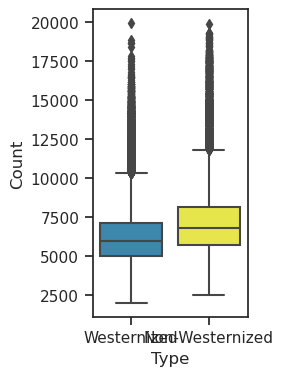

In [9]:
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [2,4]
my_pal = {"Non-Westernized": "#ffff33", "Westernized": "#2b8cbe"}
sns.boxplot(data=df_counts, x='Type', y='Count', palette=my_pal)
scipy.stats.wilcoxon(df_counts[df_counts.Type == 'Westernized'].Count, df_counts[df_counts.Type == 'Non-Westernized'].Count)
plt.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/u90_count.svg')

In [ ]:
print(df_counts[df_counts.Type == 'Westernized'].Count.mean())
print(df_counts[df_counts.Type == 'Non-Westernized'].Count.mean())

WilcoxonResult(statistic=126787577.0, pvalue=1.3405226280180577e-141)

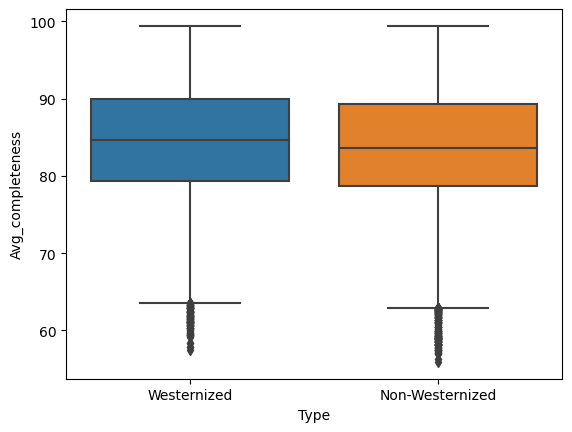

In [7]:
sns.boxplot(data=df_counts, x='Type', y='Avg_completeness')
scipy.stats.wilcoxon(df_counts[df_counts.Type == 'Westernized'].Avg_completeness, df_counts[df_counts.Type == 'Non-Westernized'].Avg_completeness)

In [ ]:
print(df_counts[df_counts.Type == 'Westernized'].Avg_completeness.mean())
print(df_counts[df_counts.Type == 'Non-Westernized'].Avg_completeness.mean())

WilcoxonResult(statistic=100235950.5, pvalue=0.0)

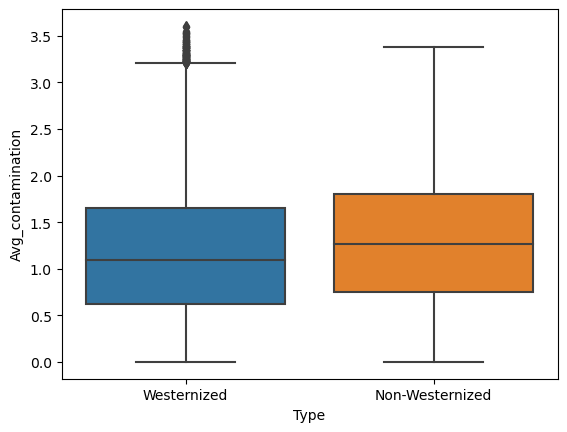

In [8]:
sns.boxplot(data=df_counts, x='Type', y='Avg_contamination')
scipy.stats.wilcoxon(df_counts[df_counts.Type == 'Westernized'].Avg_contamination, df_counts[df_counts.Type == 'Non-Westernized'].Avg_contamination)

In [ ]:
print(df_counts[df_counts.Type == 'Westernized'].Avg_contamination.mean())
print(df_counts[df_counts.Type == 'Non-Westernized'].Avg_contamination.mean())

In [ ]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

res_1 = smf.gls(formula='Count ~ Type + Avg_contamination + Avg_completeness', data=df_counts).fit()
res_2 = smf.gls(formula='Count ~ Avg_contamination + Avg_completeness', data=df_counts).fit()

result = sm.stats.anova_lm(res_2, res_1, test='Chisq')
p_anova = result['Pr(>Chisq)'][1]
p_lm = res_1.pvalues[1]

if p_lm < 0.05 and p_anova < 0.05 and res_1.rsquared > res_2.rsquared:
    print('{} {}'.format(res_1.rsquared,p_lm))

In [ ]:
res_1.summary()

In [ ]:
res_2.summary()

In [ ]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

res_1 = smf.mixedlm(formula='Count ~ Type + Avg_completeness + Avg_contamination', data=df_counts, groups=df_counts['SGB']).fit()
res_2 = smf.mixedlm(formula='Count ~ Avg_completeness + Avg_contamination', data=df_counts, groups=df_counts['SGB']).fit()

# result = sm.stats.anova_lm(res_2, res_1, test='Chisq')
# p_anova = result['Pr(>Chisq)'][1]
# p_lm = res_1.pvalues[1]

# if p_lm < 0.05 and p_anova < 0.05 and res_1.rsquared > res_2.rsquared:
#     print('{} {}'.format(res_1.rsquared,p_lm))

In [ ]:
res_1.summary()

In [ ]:
res_2.summary()

In [ ]:
u50_desc

## U50 analysis

In [ ]:
u50_to_count = dict()
for pangenome in pangenomes:
    for u50 in pangenome[2]:
        if u50_desc[u50][0] not in u50_to_count:
            u50_to_count[u50_desc[u50][0]] = 0
        u50_to_count[u50_desc[u50][0]] += 1
len(u50_to_count)

In [ ]:
u50_to_count

In [ ]:
## Description based
def parallel_pangenome_enrichment_description(pangenome):
    sgb = pangenome[0]
    w = sgb2mags[sgb]['w']
    nw = sgb2mags[sgb]['nw']
    
    pvalues = list()
    results = list()    
    pangenome_des = dict()
    
    for u50 in pangenome[2]:
        if u50_desc[u50][0] not in pangenome_des:
            pangenome_des[u50_desc[u50][0]] = set()  
        for x in pangenome[2][u50]:
            pangenome_des[u50_desc[u50][0]].add(x)
   
    for u50 in pangenome_des:     
        w50 = len([x for x in w if x in pangenome_des[u50]])
        nw50 = len([x for x in nw if x in pangenome_des[u50]])
        fisher_table = np.array([[w50, nw50],[len(w) - w50, len(nw) - nw50]])
        oddsr, p = fisher_exact(fisher_table, alternative='two-sided')
        pvalues.append(p)
        results.append([sgb, u50, w50, nw50, len(w), len(nw), oddsr, p])
        
    _, qvalues = fdrcorrection(pvalues, method='poscorr')
    
    for i, q in enumerate(qvalues):
        results[i].append(q)
        
    print('SGB{} {} {}'.format(sgb, len([x for x in results if x[-1] < 0.2]), len(results)))
    return [x for x in results if x[-1] < 0.2]

In [ ]:
final_results = execute_pool(((parallel_pangenome_enrichment_description, pangenome) for pangenome in pangenomes), 50)

In [ ]:
u50_desc[u50]

In [ ]:
## U50 based
def parallel_pangenome_enrichment(pangenome):
    sgb = pangenome[0]
    w = sgb2mags[sgb]['w']
    nw = sgb2mags[sgb]['nw']
    pvalues = list()
    results = list()
    for u50 in pangenome[2]:
        w50 = len([x for x in w if x in pangenome[2][u50]])
        nw50 = len([x for x in nw if x in pangenome[2][u50]])
        fisher_table = np.array([[w50, nw50],[len(w) - w50, len(nw) - nw50]])
        oddsr, p = fisher_exact(fisher_table, alternative='two-sided')
        pvalues.append(p)
        results.append([sgb, u50, w50, nw50, len(w), len(nw), oddsr, p])
    _, qvalues = fdrcorrection(pvalues, method='poscorr')
    for i, q in enumerate(qvalues):
        results[i].append(q)
    print('SGB{} {} {}'.format(sgb, len([x for x in results if x[-1] < 0.2]), len(results)))
    return [x for x in results if x[-1] < 0.2]

In [ ]:
final_results = execute_pool(((parallel_pangenome_enrichment, pangenome) for pangenome in pangenomes), 50)

In [ ]:
for f in final_results:
    print(f)
    break

In [ ]:
gene2count_w = dict()
gene2count_nw = dict()
gene2count_clust_w = dict()
gene2count_clust_nw = dict()
for f in final_results:
    for res in f:
        if res[-1] < 0.01:
            if res[1] not in gene2count_w:
                gene2count_w[res[1]] = 0
                gene2count_nw[res[1]] = 0
                gene2count_clust_w[res[1]] = 0
                gene2count_clust_nw[res[1]] = 0
            if res[2]/res[4] > res[3]/res[5]:
                gene2count_w[res[1]] += 1
                if res[0] in enr:
                    gene2count_clust_w[res[1]] += 1                    
            elif res[2]/res[4] < res[3]/res[5]:
                gene2count_nw[res[1]] += 1
                if res[0] in enr:
                    gene2count_clust_nw[res[1]] += 1
                
# {k: v for k, v in sorted(gene2count_nw.items(), key=lambda item: item[1], reverse=True)}

In [ ]:
{k: v for k, v in sorted(gene2count_clust_nw.items(), key=lambda item: item[1], reverse=True)}

In [ ]:
u50_desc = dict()
with open('/shares/CIBIO-Storage/CM/scratch/databases/UniRef50_201906.headers') as rf:
    for line in rf:
        u50_desc[line.split(' ')[0][1:]] = [line.split(line.split(' ')[0][1:])[1].split('n=')[0].strip(), line.split('RepID=')[1].strip()]
u50_desc['UniRef50_unknown'] = ['Unknown', 'Unknown']
u50_desc

In [ ]:
w_enr_f = pd.DataFrame.from_dict({k: v for k, v in sorted(gene2count_w.items(), key=lambda item: item[1], reverse=True)}, orient='index')
w_enr_f.columns = ['Westernized']
nw_enr_f = pd.DataFrame.from_dict({k: v for k, v in sorted(gene2count_nw.items(), key=lambda item: item[1], reverse=True)}, orient='index')
nw_enr_f.columns = ['Non-Westernized']
function_enr = w_enr_f.join(nw_enr_f)
w_enr_f = pd.DataFrame.from_dict({k: v for k, v in sorted(gene2count_clust_w.items(), key=lambda item: item[1], reverse=True)}, orient='index')
w_enr_f.columns = ['Westernized_Clust']
nw_enr_f = pd.DataFrame.from_dict({k: v for k, v in sorted(gene2count_clust_nw.items(), key=lambda item: item[1], reverse=True)}, orient='index')
nw_enr_f.columns = ['Non-Westernized_Clust']
function_enr = function_enr.join(w_enr_f)
function_enr = function_enr.join(nw_enr_f)
# function_enr['Non-Westernized_Clust_perc'] = function_enr['Non-Westernized_Clust'] / len([x for x in enr if x in [y[0] for y in pangenomes]]) * 100
function_enr['SGB_count'] = [u50_to_count[x] for x in function_enr.index]
function_enr['Westernized_perc'] = function_enr['Westernized'] / function_enr['SGB_count'] * 100
function_enr['Non-Westernized_perc'] = function_enr['Non-Westernized'] / function_enr['SGB_count'] * 100
# function_enr['Description'] = [u50_desc[x][0] for x in function_enr.index]
# function_enr['UniRef'] = [u50_desc[x][1] for x in function_enr.index]
function_enr = function_enr[(function_enr['SGB_count'] >= 0.1 * len(final_results)) & ((function_enr['Westernized_perc'] >= 10) | (function_enr['Non-Westernized_perc'] >= 10))]
function_enr

In [ ]:
function_enr.to_csv('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/nw_function_enrichment_desc.tsv', sep='\t')

In [ ]:
nw_enr_u50 = [x for x in function_enr[(function_enr['Non-Westernized'] > 10) & (function_enr['Westernized'] < 10)].index.tolist() if '_unknown' not in x]

In [ ]:
# rx = list()
# with open('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/tools/humann/humann/data/pathways/metacyc_reactions_level4ec_only.uniref') as rf:
#     for line in rf:
#         for u50 in nw_enr_u50:
#             if u50 in line:
#                 rx.append(line.strip().split('\t')[0])
#                 break
path = list()
with open('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/tools/humann/humann/data/pathways/metacyc_pathways') as rf:
    for line in rf:
        for r in rx:
            reaction = line.strip().split(' \t')[1]
            reaction.split(',')
            if r in line:
                path.append(line.strip().split('\t')[0])
                break
path_names = list()
import gzip
with gzip.open('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/tools/humann/humann/data/misc/map_metacyc-pwy_name.txt.gz', 'rt') as rf:
    for line in rf:
        for p in path:
            if p in line:
                path_names.append(line.strip().split('\t')[1])
                break
len(path_names)

In [ ]:
path_names

## Enriched clusters analysis

In [ ]:
enriched_sgbs = pd.read_table('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/nw_enriched_clusterwnw.tsv', sep='\t', index_col=[0])
enriched_sgbs.index = [x.split('_')[0][3:] for x in enriched_sgbs.index]
enriched_sgbs

In [ ]:
cluster_yes = dict()
cluster_no = dict()
enr = enriched_sgbs.index.tolist()
for pangenome in pangenomes:
    for u50 in set(list(pangenome[2].keys())):
        if pangenome[0] in enr:
            if u50 not in cluster_yes:
                cluster_yes[u50] = 0            
            cluster_yes[u50] += 1
        else:            
            if u50 not in cluster_no:
                cluster_no[u50] = 0            
            cluster_no[u50] += 1

In [ ]:
results = list()
pvalues = list()
enr_not = len([x for x in enr if x not in [y[0] for y in pangenomes]])
for u50 in set(list(cluster_yes.keys()) +  list(cluster_no.keys())):
    yes = 0 if u50 not in cluster_yes else cluster_yes[u50] 
    no = 0 if u50 not in cluster_no else cluster_no[u50] 
    n_yes = (len(enr) - enr_not) - yes
    n_no = len(pangenomes) - (len(enr) - enr_not) - no 
    fisher_table = np.array([[yes, no],[n_yes, n_no]])
    oddsr, p = fisher_exact(fisher_table, alternative='two-sided')
    pvalues.append(p)
    results.append([u50, yes, no, n_yes, n_no, oddsr, p])
_, qvalues = fdrcorrection(pvalues, method='poscorr')
for i, q in enumerate(qvalues):
    results[i].append(q)

In [ ]:
df_clus = pd.DataFrame.from_dict({x[0]:x[1:] for x in results if x[-1] < 0.01}, orient='index')
df_clus.columns = ['ClusterEnr', 'NoClusterEnr', 'Wno', 'NWno', 'odds', 'pvalue', 'FDR']
df_clus['ClusterCount'] = df_clus['ClusterEnr']  + df_clus['Wno'] 
df_clus['NoClusterCount'] = df_clus['NoClusterEnr']  + df_clus['NWno'] 
df_clus['Description'] = [u50_desc[x][0] for x in df_clus.index]
df_clus

In [ ]:
df_clus.to_csv('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/nw_function_clus_enr.tsv', sep='\t')

In [ ]:
path = list()
with open('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/tools/humann/humann/data/pathways/metacyc_pathways_structured') as rf:
    for line in rf:
        reaction = line.strip().split('\t')[1]
        print(reaction)
        reaction = reaction.strip().split(' ')
        print(reaction)
        break

## Genetic vs genomic distance

In [ ]:
distances = pd.read_table('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/nw_distances_final.tsv', sep=',', index_col=[0])
distances.index = [x[6:].replace('_group','') for x in distances.index]
distances

In [ ]:
a1 = pd.DataFrame(distances['NW_avg_dist'])
a1['Lifestyle'] = 'non-Westernized'
a1.columns = ['AVG dist', 'Lifestyle']
a2 = pd.DataFrame(distances['W_avg_dist'])
a2['Lifestyle'] = 'Westernized'
a2.columns = ['AVG dist', 'Lifestyle']
aux = a2.append(a1)

In [ ]:
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [2,4]
my_pal = {"non-Westernized": "#ffff33", "Westernized": "#2b8cbe"}
sns.boxplot(data=aux, x='Lifestyle', y='AVG dist', palette=my_pal)
scipy.stats.wilcoxon(aux[aux.Lifestyle == 'Westernized']['AVG dist'], aux[aux.Lifestyle == 'non-Westernized']['AVG dist'])
# plt.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/dist_box.svg')

In [ ]:
poly = pd.read_table('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/nw_poly_final.tsv', sep=',', index_col=[0])
poly.index = [x[6:].replace('_group','') for x in poly.index]
poly

In [ ]:
a1 = pd.DataFrame(poly['NW_avg_poly'])
a1['Lifestyle'] = 'non-Westernized'
a1.columns = ['AVG polymorphisms', 'Lifestyle']
a2 = pd.DataFrame(poly['W_avg_poly'])
a2['Lifestyle'] = 'Westernized'
a2.columns = ['AVG polymorphisms', 'Lifestyle']
aux = a2.append(a1)

In [ ]:
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [2,4]
my_pal = {"non-Westernized": "#ffff33", "Westernized": "#2b8cbe"}
sns.boxplot(data=aux, x='Lifestyle', y='AVG polymorphisms', palette=my_pal)
scipy.stats.wilcoxon(aux[aux.Lifestyle == 'Westernized']['AVG polymorphisms'], aux[aux.Lifestyle == 'non-Westernized']['AVG polymorphisms'])
# plt.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/poly_box.svg')

In [5]:

df_counts = pd.read_csv('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/nw_counts_u90.tsv', sep='\t')
df_counts

,Unnamed: 0,SGB,Iteration,Count,Type,Avg_completeness,Avg_contamination
0,1667__w__0,1667,0,6069,Westernized,70.490751,0.283918
1,1667__nw__0,1667,0,5998,Non-Westernized,70.481083,0.463979
2,1667__w__1,1667,1,5819,Westernized,69.230502,0.379875
3,1667__nw__1,1667,1,6036,Non-Westernized,70.974583,0.500979
4,1667__w__2,1667,2,5673,Westernized,70.254826,0.297142
...,...,...,...,...,...,...,...
49891,10068__nw__96,10068,96,11782,Non-Westernized,98.002023,0.444147
49892,10068__w__97,10068,97,12526,Westernized,98.045051,0.702542
49893,10068__nw__97,10068,97,10606,Non-Westernized,98.323402,0.329244
49894,10068__w__98,10068,98,12118,Westernized,98.313353,0.404281


In [6]:
res = dict()
for sgb in distances.index:
    if int(sgb) in df_counts['SGB'].tolist():
        print(sgb)
        sgb_counts = df_counts[df_counts['SGB'] == int(sgb)]
    #     print(sgb_counts)
        w_c_mean = sgb_counts[sgb_counts['Type']=='Westernized']['Count'].mean()
        nw_c_mean = sgb_counts[sgb_counts['Type']=='Non-Westernized']['Count'].mean()
        print(w_c_mean, nw_c_mean)
        fold_change_genes = (nw_c_mean - w_c_mean)/w_c_mean
        fold_change_dist = (distances.loc[sgb, 'NW_avg_dist'] - distances.loc[sgb, 'W_avg_dist'])/distances.loc[sgb, 'W_avg_dist']
        res[sgb] = [fold_change_dist, fold_change_genes]

NameError: name 'distances' is not defined

In [ ]:
df_print = pd.DataFrame.from_dict(res).transpose()
df_print.columns = ['Fold change nGD', 'Fold change gene content']
df_print['SGB type'] = [ sgb2known[x] for x in df_print.index.tolist()]
df_print

In [ ]:
from scipy import stats
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [4,4]
my_pal = {"kSGB": "#55a868", "uSGB": "#dd8452"}
sns.regplot(data=df_print, y='Fold change gene content', x='Fold change nGD', color='#444444', scatter=False)
g = sns.scatterplot(data=df_print, x='Fold change nGD',  y='Fold change gene content',alpha=0.75, s=60, hue='SGB type', palette=my_pal)
# g.set(ylim=(-0.4, 1.5))
# g.set(xlim=(-0.4, 1.5))
print(stats.pearsonr(df_print['Fold change nGD'], df_print['Fold change gene content']))
# plt.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/genetic_genoimc.svg')

In [ ]:
res = list()
for sgb in distances.index:
    if int(sgb) in df_counts['SGB'].tolist():
        print(sgb)
        sgb_counts = df_counts[df_counts['SGB'] == int(sgb)]
    #     print(sgb_counts)
        w_c_mean = sgb_counts[sgb_counts['Type']=='Westernized']['Count'].mean()
        nw_c_mean = sgb_counts[sgb_counts['Type']=='Non-Westernized']['Count'].mean()
        res.append([w_c_mean, distances.loc[sgb, 'W_avg_dist'], 'Westernized'])
        res.append([nw_c_mean, distances.loc[sgb, 'NW_avg_dist'], 'non-Westernized'])

In [ ]:
df_print = pd.DataFrame(res)
df_print.columns = ['AVG gene content','AVG nGD', 'Lifestyle']
# df_print['SGB type'] = [ sgb2known[x] for x in df_print.index.tolist()]
df_print

In [ ]:
from scipy import stats
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [4,4]
# my_pal = {"kSGB": "#55a868", "uSGB": "#dd8452"}
# sns.regplot(data=df_print, y='AVG gene content', x='AVG nGD', color='#444444', scatter=False)
g = sns.scatterplot(data=df_print, x='AVG nGD',  y='AVG gene content',alpha=0.55, s=40, hue='Lifestyle')
# g.set(ylim=(-0.4, 1.5))
# g.set(xlim=(-0.4, 1.5))
# print(stats.pearsonr(df_print['Fold change nGD'], df_print['Fold change gene content']))
# plt.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/genetic_genoimc.svg')

## For SGB-based metaanalysis

In [ ]:
pangenomes_filt_meta = None

In [ ]:
genome2sgb = dict()
for pangenome in pangenomes:
    for u50 in pangenome[2]:
        genome2sgb.update({g:pangenome[0] for g in pangenome[2][u50]})

In [ ]:
pangenome50 = dict()
pangenome2count = dict()
for pangenome in pangenomes:
    for u50 in pangenome[2]:
        if u50_desc[u50][0] not in pangenome50:
            pangenome50[u50_desc[u50][0]] = dict()
            pangenome2count[u50_desc[u50][0]] = 0
        pangenome50[u50_desc[u50][0]].update({g:1 for g in pangenome[2][u50]})
        pangenome2count[u50_desc[u50][0]] += 1

In [ ]:
pangenomes_list = list()
for u50 in pangenome50:
    if pangenome2count[u50] >= 3:
        pangenomes_list.append(pd.Series(data=pangenome50[u50], index=pangenome50[u50].keys(), name=u50))

In [ ]:
len(pangenomes_list)

In [ ]:
pangenomes_df = pd.concat(pangenomes_list, axis=1).fillna(0)
pangenomes_df

In [ ]:
samples_ma = pangenomes_df.index.tolist()
to_drop = set()
for x in samples_ma:
    if x in sgb2mags[genome2sgb[x]]['w'] :
        pass
    elif x in sgb2mags[genome2sgb[x]]['nw']:               
        pass
    else:
        to_drop.add(x)

In [ ]:
pangenomes_df_filt = pangenomes_df.drop(to_drop, axis=0)
pangenomes_df_filt

In [ ]:
samples_ma = pangenomes_df_filt.index.tolist()
lifestyle = dict()
for x in samples_ma:
    if x in sgb2mags[genome2sgb[x]]['w'] :
        lifestyle[x] = 'Westernized'
    elif x in sgb2mags[genome2sgb[x]]['nw']:               
        lifestyle[x] = 'non-Westernized'
sgbs = {x: genome2sgb[x] for x in samples_ma if x not in to_drop}
completeness = {x: genome2quality[x][0] for x in samples_ma if x not in zoe2metaref and x not in to_drop}
completeness.update({x: genome2quality[zoe2metaref[x]][0] for x in samples_ma if x in zoe2metaref and x not in to_drop})
contamination = {x: genome2quality[x][1] for x in samples_ma if x not in zoe2metaref and x not in to_drop}
contamination.update({x: genome2quality[zoe2metaref[x]][1] for x in samples_ma if x in zoe2metaref and x not in to_drop})

In [ ]:
metadata = pd.concat([pd.Series(sgbs), pd.Series(completeness), pd.Series(contamination), pd.Series(lifestyle)], axis=1)
metadata.columns = ['SGB', 'Completeness', 'Contamination', 'Lifestyle']
metadata

In [ ]:
pangenomes_df_filt = pangenomes_df_filt.drop(pangenomes_df_filt.loc[pangenomes_df_filt.sum(axis=1) == 0].index.tolist())
pangenomes_df_filt = pangenomes_df_filt.transpose()
pangenomes_df_filt = pangenomes_df_filt.drop(pangenomes_df_filt.loc[pangenomes_df_filt.sum(axis=1) == 0].index.tolist())
pangenomes_df_filt = pangenomes_df_filt.transpose()

In [ ]:
pangenomes_df_filt.columns = ['f__'+x for x in pangenomes_df_filt.columns.tolist()]

In [ ]:
pangenomes_filt_meta = pd.concat([metadata.transpose(), pangenomes_df_filt.transpose()])
pangenomes_filt_meta

In [ ]:
pangenomes_filt_meta.to_csv('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/meta-analysis/u50_sgbs.tsv', sep='\t')

### Filtered meta-analysis

In [ ]:
headers_meta = pd.read_csv('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/meta-analysis/u50_headers.tsv', sep='\t', index_col=[0])

In [ ]:
headers_meta

In [ ]:
tot_len = 0
for sgb in set(headers_meta.loc['SGB'].tolist()):
    tmp = headers_meta.T.loc[headers_meta.loc['SGB'] == sgb]    
#     tmp = tmp.loc[tmp['Completeness'].astype(float) > 90]
    tot_len += len(tmp[tmp['Lifestyle'] == 'Westernized']) + len(tmp[tmp['Lifestyle'] == 'non-Westernized'])
    print(sgb, len(tmp[tmp['Lifestyle'] == 'Westernized']),len(tmp[tmp['Lifestyle'] == 'non-Westernized']))

In [ ]:
tot_len

## SGBs with more differential u90s

In [46]:
import statsmodels.formula.api as smf
import statsmodels.api as sm
import statsmodels
import math

In [ ]:
import warnings
warnings.filterwarnings('ignore')
from tqdm import tqdm

In [65]:
sgb2tax = dict()
with bz2.open('/shares/CIBIO-Storage/CM/scratch/databases/MetaRefSGB/releases/Jan21/SGB.Jan21.txt.bz2', 'rt')as rf:
    for line in rf:
        if line.startswith('SGB'):
            line = line.strip().split('\t')
            sgb2tax[line[1]] = line[9]
        elif line.startswith('GGB'):
            break
sgb2tax

{'1': 'k__Bacteria|p__Firmicutes|c__CFGB1|o__OFGB1|f__FGB1|g__GGB1|s__GGB1_SGB1|t__SGB1',
 '2': 'k__Archaea|p__Nanoarchaeota|c__CFGB1|o__OFGB1|f__FGB1|g__GGB2|s__GGB2_SGB2|t__SGB2',
 '4': 'k__Bacteria|p__Proteobacteria|c__CFGB2|o__OFGB2|f__FGB2|g__GGB4|s__GGB4_SGB4|t__SGB4',
 '5': 'k__Bacteria|p__Firmicutes|c__CFGB3|o__OFGB3|f__FGB3|g__GGB5|s__GGB5_SGB5|t__SGB5',
 '8': 'k__Archaea|p__Candidatus_Diapherotrites|c__CFGB6|o__OFGB6|f__FGB6|g__GGB8|s__GGB8_SGB8|t__SGB8',
 '17': 'k__Bacteria|p__Bacteroidetes|c__CFGB13|o__OFGB13|f__FGB13|g__GGB16|s__GGB16_SGB17|t__SGB17',
 '19': 'k__Bacteria|p__Fusobacteria|c__CFGB15|o__OFGB15|f__FGB15|g__GGB18|s__GGB18_SGB19|t__SGB19',
 '20': 'k__Bacteria|p__Firmicutes|c__CFGB16|o__OFGB16|f__FGB16|g__GGB19|s__GGB19_SGB20|t__SGB20',
 '21': 'k__Bacteria|p__Proteobacteria|c__CFGB17|o__OFGB17|f__FGB17|g__GGB20|s__GGB20_SGB21|t__SGB21',
 '24': 'k__Bacteria|p__Proteobacteria|c__CFGB20|o__OFGB20|f__FGB20|g__GGB23|s__GGB23_SGB24|t__SGB24',
 '27': 'k__Bacteria|p__Prot

In [ ]:
resultsu90 = dict()
for i in tqdm(range(len(pangenomes))):
    pangenome = pangenomes[i]
    resultsu90[pangenome[0]] = {}
    for u90 in pangenome[1]:
        for_df = list()
        for genome in sgb2mags[pangenome[0]]['w']:
            for_df.append([genome, int(genome in pangenome[1][u90]), 'Westernized', float(genome2quality[genome][0]), float(genome2quality[genome][1])])
        for genome in sgb2mags[pangenome[0]]['nw']:
            for_df.append([genome, int(genome in pangenome[1][u90]), 'non-Westernized', float(genome2quality[genome][0]), float(genome2quality[genome][1])])
        df_u90 = pd.DataFrame(for_df)
        df_u90.columns = ['Genome', 'Presence', 'Lifestyle', 'Completeness', 'Contamination']
        res_1 = smf.gls(formula='Presence ~ Lifestyle + Completeness + Contamination', data=df_u90).fit()
        resultsu90[pangenome[0]][u90] = [res_1.rsquared, res_1.pvalues[1]]

In [41]:
len(resultsu90)

252

In [ ]:
threshold = 0.05

In [70]:
to_df = list()
for sgb in resultsu90:
    sig = 0
    p_values = []
    filt_res = {}
    for u90, res in resultsu90[sgb].items():
        if not math.isnan(res[1]):
            p_values.append(res[1])
            filt_res[u90] = res
    fdrs = statsmodels.stats.multitest.fdrcorrection(p_values)
    keys = list(filt_res.keys())
    for i, qvalue in enumerate(fdrs[1]):
        if qvalue < threshold:
            sig += 1
    to_df.append([sgb2tax[sgb], sig])
df = pd.DataFrame(to_df)
df.columns = ['SGB', 'Diff_u90']
df

,SGB,Diff_u90
0,k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o_...,7
1,k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o_...,142
2,k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o_...,33
3,k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o_...,159
4,k__Archaea|p__Euryarchaeota|c__Methanobacteria...,1502
...,...,...
247,k__Bacteria|p__Actinobacteria|c__Actinobacteri...,4249
248,k__Bacteria|p__Actinobacteria|c__Actinobacteri...,1612
249,k__Bacteria|p__Proteobacteria|c__Deltaproteoba...,5869
250,k__Bacteria|p__Proteobacteria|c__Gammaproteoba...,1905


In [73]:
df.to_csv('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/nw_rank_func_sgb.tsv', sep='\t')

## SGBs with more differential u50s

In [ ]:
resultsu50 = dict()
for pangenome in pangenomes:
    resultsu50[pangenome[0]] = {}
    for u50 in pangenome[2]:
        for_df = list()
        for genome in sgb2mags[pangenome[0]]['w']:
            for_df.append([genome, int(genome in pangenome[2][u50]), 'Westernized', float(genome2quality[genome][0]), float(genome2quality[genome][1])])
        for genome in sgb2mags[pangenome[0]]['nw']:
            for_df.append([genome, int(genome in pangenome[2][u50]), 'non-Westernized', float(genome2quality[genome][0]), float(genome2quality[genome][1])])
        df_u50 = pd.DataFrame(for_df)
        df_u50.columns = ['Genome', 'Presence', 'Lifestyle', 'Completeness', 'Contamination']
        res_1 = smf.gls(formula='Presence ~ Lifestyle + Completeness + Contamination', data=df_u50).fit()
        resultsu50[pangenome[0]][u50] = [res_1.rsquared, res_1.pvalues[1]]